In [37]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.4.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch==2.4 and torchvision==0.17.2 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch==2.4
    torchvision 0.17.2 depends on torch==2.2.2

Additionally, some packages in these conflicts have no matching distributions available for your environment:
    torch

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency

In [38]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Data Pipeline

In [39]:
df = pd.read_csv("GALAXY_DATASET/final_15000.csv")
df.head()

,dr7objid,asset_id,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t02_edgeon_a04_yes_debiased,t03_bar_a06_bar_debiased,t04_spiral_a08_spiral_debiased,t08_odd_feature_a24_merger_debiased,t08_odd_feature_a22_irregular_debiased
0,587722981742018657,15,0.003,0.955,0.000000,0.000000,0.733360,0.003648,0.526693
1,587722981744050315,35,0.000,0.981,0.000289,0.402361,0.998695,0.000000,0.045512
2,587722981746016481,63,0.020,0.973,0.000000,0.216366,0.995563,0.000000,0.437910
3,587722981747654761,81,0.766,0.757,0.108623,0.381713,0.926622,0.000000,0.889990
4,587722981747982465,89,0.154,0.846,0.003660,0.885386,0.839584,0.211087,0.340519


In [40]:
img_folder = "GALAXY_DATASET/Images Differing sizes/224"

# 10 images are missing from the folder, drop those rows
valid = set(int(f.replace(".jpg", "")) for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["asset_id"].isin(valid)].reset_index(drop=True)
print(len(df))  # should be 14990

607


In [41]:
def make_label(row, thresh=0.5):

    smooth    = row["t01_smooth_or_features_a01_smooth_debiased"]
    featured  = row["t01_smooth_or_features_a02_features_or_disk_debiased"]

    irregular=row["t08_odd_feature_a22_irregular_debiased"]
    bar       = row["t03_bar_a06_bar_debiased"]
    spiral    = row["t04_spiral_a08_spiral_debiased"]
    edgeon    = row["t02_edgeon_a04_yes_debiased"]
    merger = row["t08_odd_feature_a24_merger_debiased"]

    labels=[]
   

    if featured > smooth:
        labels.append("featured")
    else:
        labels.append("smooth")

    
    if irregular>bar:
        labels.append("irregular")

        if edgeon > thresh:
            labels.append("edge_on")

        if merger > thresh:
            labels.append("merger")
    
    else:

        if bar<thresh and spiral<thresh and edgeon<thresh and merger<thresh:
            labels.append("eliptical")
        
        else: 
        
            if bar>thresh:
                labels.append("barred_spiral")

            elif spiral>thresh:
                labels.append("spiral")

            if edgeon > thresh:
                labels.append("edge_on")

            if merger > thresh:
                labels.append("merger")

    if len(labels) == 0:
        return None
    return "_".join(labels)

df["label"] = df.apply(make_label, axis=1)
df = df.dropna(subset=["label"]).reset_index(drop=True)
print(df["label"].value_counts())

label
smooth_eliptical                     111
featured_barred_spiral                98
featured_spiral                       86
featured_irregular                    78
smooth_irregular                      51
featured_eliptical                    46
smooth_spiral                         29
featured_edge_on                      26
smooth_barred_spiral                  25
smooth_edge_on                        10
featured_irregular_edge_on             9
featured_barred_spiral_edge_on         6
featured_barred_spiral_merger          5
featured_spiral_edge_on                5
featured_spiral_merger                 5
smooth_merger                          4
featured_irregular_merger              2
smooth_barred_spiral_edge_on           2
smooth_spiral_merger                   2
smooth_irregular_edge_on               2
featured_edge_on_merger                1
featured_irregular_edge_on_merger      1
smooth_spiral_edge_on                  1
smooth                                 1
featured_m

In [42]:
classes = sorted(df["label"].dropna().unique())

print(classes)
print(f"Number of classes: {len(classes)}")

class_to_idx = {c:i for i, c in enumerate(classes)}
idx_to_class = {i:c for c, i in class_to_idx.items()}

['featured_barred_spiral', 'featured_barred_spiral_edge_on', 'featured_barred_spiral_merger', 'featured_edge_on', 'featured_edge_on_merger', 'featured_eliptical', 'featured_irregular', 'featured_irregular_edge_on', 'featured_irregular_edge_on_merger', 'featured_irregular_merger', 'featured_merger', 'featured_spiral', 'featured_spiral_edge_on', 'featured_spiral_merger', 'smooth', 'smooth_barred_spiral', 'smooth_barred_spiral_edge_on', 'smooth_edge_on', 'smooth_eliptical', 'smooth_irregular', 'smooth_irregular_edge_on', 'smooth_merger', 'smooth_spiral', 'smooth_spiral_edge_on', 'smooth_spiral_merger']
Number of classes: 25


In [43]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.img_dir, f"{int(row['asset_id'])}.jpg")
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

In [44]:
# Remove classes with fewer than 10 samples
label_counts = df["label"].value_counts()
df = df[df["label"].isin(label_counts[label_counts >= 10].index)].reset_index(drop=True)
print(df["label"].value_counts())

# Create numeric label column
label_classes = sorted(df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(label_classes)}
df["label_idx"] = df["label"].map(label_to_idx)

print(f"Number of classes: {len(label_classes)}")
print(label_to_idx)

#made with claude shouldn't use^^^^^ figure out issues
#####################################################

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_loader = DataLoader(GalaxyDataset(train_df, img_folder, train_tfms), batch_size=32, shuffle=True,  num_workers=1)
val_loader   = DataLoader(GalaxyDataset(val_df,   img_folder, val_tfms),   batch_size=32, shuffle=False, num_workers=1)
test_loader  = DataLoader(GalaxyDataset(test_df,  img_folder, val_tfms),   batch_size=32, shuffle=False, num_workers=1)

print(f"train: {len(train_loader.dataset)}  val: {len(val_loader.dataset)}  test: {len(test_loader.dataset)}")

label
smooth_eliptical          111
featured_barred_spiral     98
featured_spiral            86
featured_irregular         78
smooth_irregular           51
featured_eliptical         46
smooth_spiral              29
featured_edge_on           26
smooth_barred_spiral       25
smooth_edge_on             10
Name: count, dtype: int64
Number of classes: 10
{'featured_barred_spiral': 0, 'featured_edge_on': 1, 'featured_eliptical': 2, 'featured_irregular': 3, 'featured_spiral': 4, 'smooth_barred_spiral': 5, 'smooth_edge_on': 6, 'smooth_eliptical': 7, 'smooth_irregular': 8, 'smooth_spiral': 9}
train: 392  val: 84  test: 84


## Model

In [45]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# freeze everything
for param in model.parameters():
    param.requires_grad = False

# swap the head for 4 classes
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

## Training

In [46]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct = 0.0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct += (out.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n

### Phase 1 — train head only (backbone frozen)

In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

EPOCHS_P1 = 5
best_val_acc = 0.0

for epoch in range(EPOCHS_P1):
    tl, ta = run_epoch(model, train_loader, criterion, optimizer)
    vl, va = run_epoch(model, val_loader,   criterion)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), "best_model.pth")

    print(f"epoch {epoch+1}/{EPOCHS_P1}  train_loss={tl:.4f}  val_loss={vl:.4f}  train_acc={ta:.4f}  val_acc={va:.4f}")

epoch 1/5  train_loss=2.4763  val_loss=2.3701  train_acc=0.1658  val_acc=0.2024
epoch 2/5  train_loss=2.0883  val_loss=2.2269  train_acc=0.2653  val_acc=0.2738
epoch 3/5  train_loss=2.0137  val_loss=2.1583  train_acc=0.3036  val_acc=0.2738
epoch 4/5  train_loss=1.9714  val_loss=2.1187  train_acc=0.3112  val_acc=0.2381
epoch 5/5  train_loss=1.9359  val_loss=2.0940  train_acc=0.3112  val_acc=0.2619


### Phase 2 — unfreeze everything and fine-tune

In [48]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(),  "lr": 1e-3},
    {"params": [p for name, p in model.named_parameters() if "fc" not in name], "lr": 1e-4}
])

EPOCHS_P2 = 10

for epoch in range(EPOCHS_P2):
    tl, ta = run_epoch(model, train_loader, criterion, optimizer)
    vl, va = run_epoch(model, val_loader,   criterion)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), "best_model.pth")

    print(f"epoch {EPOCHS_P1+epoch+1}/{EPOCHS_P1+EPOCHS_P2}  train_loss={tl:.4f}  val_loss={vl:.4f}  train_acc={ta:.4f}  val_acc={va:.4f}")

print(f"\nbest val acc: {best_val_acc:.4f}")

epoch 6/15  train_loss=1.8517  val_loss=2.0235  train_acc=0.3393  val_acc=0.2738
epoch 7/15  train_loss=1.6810  val_loss=2.1005  train_acc=0.4158  val_acc=0.2976
epoch 8/15  train_loss=1.5308  val_loss=2.1092  train_acc=0.4719  val_acc=0.2619
epoch 9/15  train_loss=1.4373  val_loss=2.1506  train_acc=0.4592  val_acc=0.3214
epoch 10/15  train_loss=1.3450  val_loss=2.1371  train_acc=0.5102  val_acc=0.2619
epoch 11/15  train_loss=1.2714  val_loss=2.2193  train_acc=0.5459  val_acc=0.2619
epoch 12/15  train_loss=1.2187  val_loss=2.4073  train_acc=0.5485  val_acc=0.2976
epoch 13/15  train_loss=1.1345  val_loss=2.5186  train_acc=0.5714  val_acc=0.2857
epoch 14/15  train_loss=1.0611  val_loss=2.4331  train_acc=0.6173  val_acc=0.2857
epoch 15/15  train_loss=0.9275  val_loss=2.5886  train_acc=0.7015  val_acc=0.2976

best val acc: 0.3214


## Results

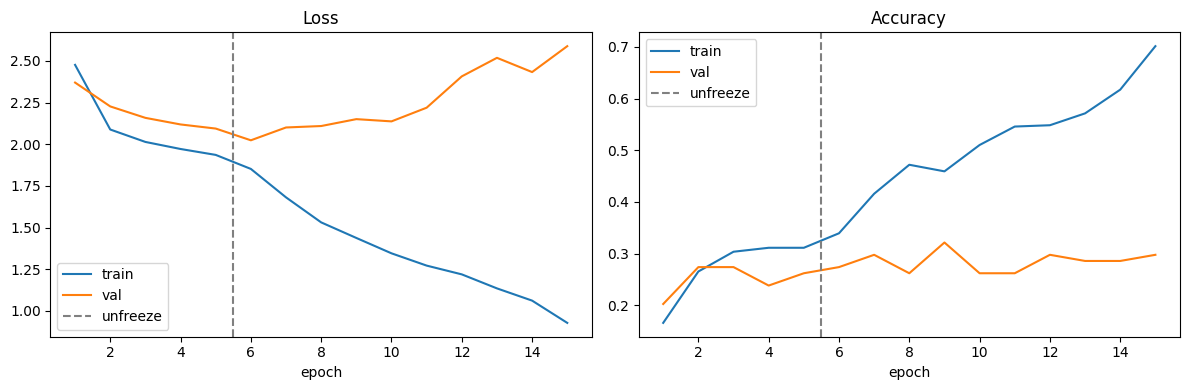

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["val_loss"],   label="val")
ax1.axvline(EPOCHS_P1 + 0.5, color="gray", linestyle="--", label="unfreeze")
ax1.set_title("Loss")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["val_acc"],   label="val")
ax2.axvline(EPOCHS_P1 + 0.5, color="gray", linestyle="--", label="unfreeze")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.legend()

plt.tight_layout()
plt.show()

test accuracy: 0.3690


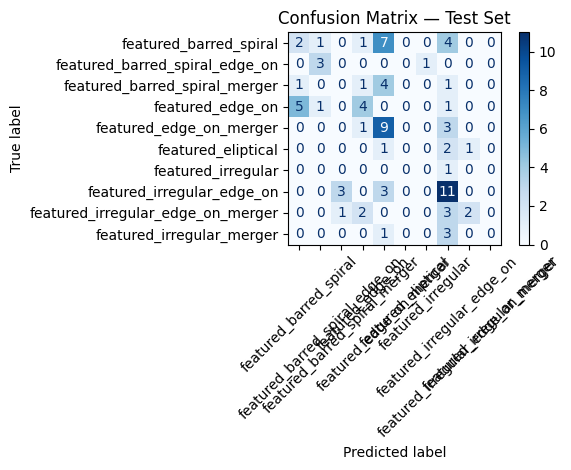

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"test accuracy: {test_acc:.4f}")
present_classes = [classes[i] for i in sorted(set(all_labels) | set(all_preds))]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=present_classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()